In [1]:
import numpy as np
import torch

from sandbox.jordan8 import *
import matplotlib.pyplot as plt
import re
import os

In [2]:
from sandbox.plt_dict import matplotlib_update
matplotlib_update()

# 1. 

In [2]:
model = JordanNet(encode_dim=32)
pretrained_dimensions = [4, 6, 9, 12, 15, 28] + [35, 33, 25, 23, 19, 13, 7]
for dim in pretrained_dimensions:
    model.add_dimension(dim)

model.load_state_dict(torch.load(f"sandbox/model_jordan8_modified.pth", map_location="cpu"))
model.eval()

C:\Users\micha\AppData\Local\Temp\ipykernel_25084\485095138.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8_modi

JordanNet(
  (encoders): ModuleDict(
    (4): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=16, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (6): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=36, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (9): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=81, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias

In [3]:
def test_matrix(A):
    # print(np.linalg.eigvals(A))
    d = A.shape[0]
    features = [per_power_features(A)]
    features = torch.tensor(features, dtype=torch.float32)
    logits = model(d, features)
    probs = torch.softmax(logits, dim=-1)
    
    return probs

In [11]:
eps = 0
T1 = np.zeros((4,4))
T1[:2,0] = np.random.randn(2)
T1[:2,2] = np.random.randn(2)

H1 = np.zeros((4,4))
H1[0,0], H1[1,1], H1[3,2], H1[2,3] = 1, 1, 1, 1

K1 = np.zeros((4,4)) + np.diag(np.ones(2), k=2) + np.diag(np.ones(2), k=-2)

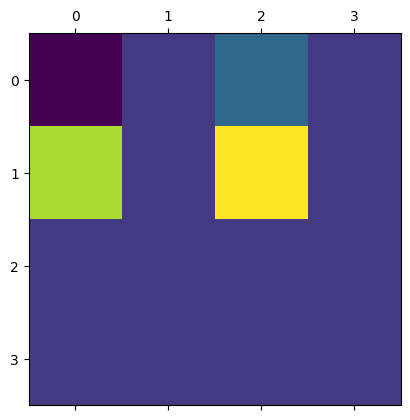

In [12]:
plt.matshow(T1)

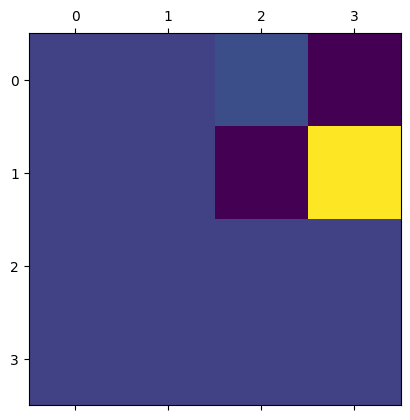

In [13]:
plt.matshow(T1 @ H1@T1.T@K1)

C:\Users\micha\AppData\Local\Temp\ipykernel_24236\3228777024.py:5: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  features = torch.tensor(features, dtype=torch.float32)


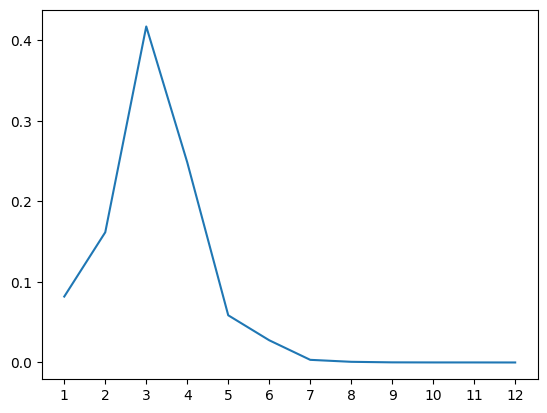

In [6]:
eps = 0
T1 = np.zeros((4,4))
T1[:2,0] = np.random.randn(2)
T1[:2,2] = np.random.randn(2)

H1 = np.zeros((4,4))
H1[0,0], H1[1,1], H1[3,2], H1[2,3] = 1, 1, 1, 1

K1 = np.zeros((4,4)) + np.diag(np.ones(2), k=2) + np.diag(np.ones(2), k=-2)

H2 = np.zeros((8,8))
H2[:4, :4] = H1
H2[4:6, 6:8] = np.eye(2)
H2[6:8, 4:6] = np.eye(2)

K2 = np.zeros((8,8))
K2[:4, :4] = K1
K2[4:6, 6:8] = np.eye(2)
K2[6:8, 4:6] = np.eye(2)

T2 = np.zeros((8,8))
T2[:4,:4] = T1
T2[:4,5:7] = np.random.randn(4,2)
T2[5:7,:4] = np.random.randn(2,4)
T2[5:7,5:7] = np.random.randn(2,2)

H3 = np.zeros((13,13))
H3[:8,:8] = H2
H3[8, 8] = 1
H3[9:11, 11:] = np.eye(2)
H3[11:, 9:11] = np.eye(2)

K3 = np.zeros((12,12))
K3[:8,:8] = K2
K3[8:10, 10:] = np.eye(2)
K3[10:, 8:10] = np.eye(2)

T3 = np.zeros((12, 13))
T3[:8, :8] = T2
T3[:8, 9:11] = np.random.randn(8,2)
T3[8:10, :8] = np.random.randn(2,8)
T3[8:10, 9:11] = np.random.randn(2,2)

T3_star = H3 @ T3.T @ K3

TstarT = T3_star @ T3
TTstar = T3 @ T3_star
prob1 = test_matrix(TstarT + np.random.randn(13, 13) / np.sqrt(13) * eps)
cls1 = torch.argmax(prob1)
prob2 = test_matrix(TTstar + np.random.randn(12, 12) / np.sqrt(12) * eps)
cls2 = torch.argmax(prob2)

plt.plot(prob2.detach().numpy()[0])
plt.xticks(ticks=range(12), labels=range(1, 13))
plt.show()

In [16]:
powers = [np.eye(13)] + [x.reshape(13, 13) for x in per_power_features(TstarT)]

In [17]:
check_doubling_consistency(powers)

--------------------------------------------------
 k      residual norm        relative error
--------------------------------------------------
  1      0.0000e+00      0.0000e+00
  2      0.0000e+00      0.0000e+00
  3      0.0000e+00      0.0000e+00
  4      0.0000e+00      0.0000e+00
  5      0.0000e+00      0.0000e+00
  6      0.0000e+00      0.0000e+00
--------------------------------------------------


(array([0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0.]))

In [13]:
import numpy as np


def check_doubling_consistency(P):
    """
    Check the doubling consistency relation

        A^(2k) ?= (A^k)^2

    for numerically computed matrix powers.

    Parameters
    ----------
    P : list of ndarray
        List of computed powers where:

            P[0] = I
            P[1] = A
            P[2] = A^2
            ...
            P[m-1] = A^(m-1)

    Returns
    -------
    delta : ndarray
        Relative doubling errors.

    residuals : ndarray
        Residual norms.

    Theory
    ------
    We compute

        D_k = P[2k] - P[k] @ P[k]

    since

        P[k] ≈ A^k

    and therefore

        P[2k] ≈ A^(2k).

    Relative consistency error:

        delta_k = ||D_k|| / ||P[k]||^2

    Small values indicate internally consistent powers.
    """

    m = len(P)

    maxk = (m - 1) // 2

    if maxk < 1:
        raise ValueError("Not enough powers for doubling test.")

    delta = np.zeros(maxk)
    residuals = np.zeros(maxk)

    print("--------------------------------------------------")
    print(" k      residual norm        relative error")
    print("--------------------------------------------------")

    for k in range(1, maxk + 1):

        Ak = P[k]          # approximates A^k
        A2k = P[2 * k]     # approximates A^(2k)

        D = A2k - Ak @ Ak

        residuals[k - 1] = np.linalg.norm(D, 2)

        denom = np.linalg.norm(Ak, 2) ** 2

        if denom == 0:
            delta[k - 1] = residuals[k - 1]
        else:
            delta[k - 1] = residuals[k - 1] / denom

        print(
            f"{k:3d}    "
            f"{residuals[k - 1]:12.4e}    "
            f"{delta[k - 1]:12.4e}"
        )

    print("--------------------------------------------------")

    return delta, residuals

In [70]:
def run_test(eps):
    T1 = np.zeros((4,4))
    T1[:2,0] = np.random.randn(2)
    T1[:2,2] = np.random.randn(2)

    H1 = np.zeros((4,4))
    H1[0,0], H1[1,1], H1[3,2], H1[2,3] = 1, 1, 1, 1

    K1 = np.zeros((4,4)) + np.diag(np.ones(2), k=2) + np.diag(np.ones(2), k=-2)

    H2 = np.zeros((8,8))
    H2[:4, :4] = H1
    H2[4:6, 6:8] = np.eye(2)
    H2[6:8, 4:6] = np.eye(2)

    K2 = np.zeros((8,8))
    K2[:4, :4] = K1
    K2[4:6, 6:8] = np.eye(2)
    K2[6:8, 4:6] = np.eye(2)

    T2 = np.zeros((8,8))
    T2[:4,:4] = T1
    T2[:4,5:7] = np.random.randn(4,2)
    T2[5:7,:4] = np.random.randn(2,4)
    T2[5:7,5:7] = np.random.randn(2,2)

    H3 = np.zeros((13,13))
    H3[:8,:8] = H2
    H3[8, 8] = 1
    H3[9:11, 11:] = np.eye(2)
    H3[11:, 9:11] = np.eye(2)

    K3 = np.zeros((12,12))
    K3[:8,:8] = K2
    K3[8:10, 10:] = np.eye(2)
    K3[10:, 8:10] = np.eye(2)

    T3 = np.zeros((12, 13))
    T3[:8, :8] = T2
    T3[:8, 9:11] = np.random.randn(8,2)
    T3[8:10, :8] = np.random.randn(2,8)
    T3[8:10, 9:11] = np.random.randn(2,2)

    T3_star = H3 @ T3.T @ K3

    TstarT = T3_star @ T3
    TTstar = T3 @ T3_star
    prob1 = test_matrix(TstarT + np.random.randn(13, 13) / np.sqrt(13) * eps)
    cls1 = torch.argmax(prob1)
    prob2 = test_matrix(TTstar + np.random.randn(12, 12) / np.sqrt(12) * eps)
    cls2 = torch.argmax(prob2)

    plt.plot(prob2.detach().numpy()[0])
    plt.xticks(ticks=range(12), labels=range(1, 13))
    plt.show()

    return (cls1.item(), cls2.item()) # should return (2, 3)


In [71]:
def run_test_8(eps):
    T1 = np.zeros((4,4))
    T1[:2,0] = np.random.randn(2)
    T1[:2,2] = np.random.randn(2)

    H1 = np.zeros((4,4))
    H1[0,0], H1[1,1], H1[3,2], H1[2,3] = 1, 1, 1, 1

    K1 = np.zeros((4,4)) + np.diag(np.ones(2), k=2) + np.diag(np.ones(2), k=-2)

    H2 = np.zeros((8,8))
    H2[:4, :4] = H1
    H2[4:6, 6:8] = np.eye(2)
    H2[6:8, 4:6] = np.eye(2)

    K2 = np.zeros((8,8))
    K2[:4, :4] = K1
    K2[4:6, 6:8] = np.eye(2)
    K2[6:8, 4:6] = np.eye(2)

    T2 = np.zeros((8,8))
    T2[:4,:4] = T1
    T2[:4,5:7] = np.random.randn(4,2)
    T2[5:7,:4] = np.random.randn(2,4)
    T2[5:7,5:7] = np.random.randn(2,2)

    T2_star = H2 @ T2.T @ K2
    TTstar = np.zeros((9,9))
    TTstar[:8,:8] = T2 @ T2_star

    TstarT = np.zeros((9,9))
    TstarT[:8,:8] = T2_star @ T2

    prob1 = test_matrix(TstarT + np.random.randn(9,9) / np.sqrt(9) * eps)
    cls1 = torch.argmax(prob1)
    prob2 = test_matrix(TTstar + np.random.randn(9, 9) / np.sqrt(9) * eps)
    cls2 = torch.argmax(prob2)

    # plt.plot(prob2.detach().numpy()[0])
    # plt.xticks(ticks=range(12), labels=range(1, 13))
    # plt.show()

    return (cls1.item(), cls2.item()) # should return (2, 3)


In [72]:
results = []
for i in range(100):
    results.append(run_test_8(0))

In [73]:
results = np.array(results)

In [74]:
np.sum(results[:,0] == 2)

np.int64(59)

In [75]:
np.sum(results[:,0] == 1)

np.int64(40)

In [76]:
np.sum(results[:,1] == 1)

np.int64(100)

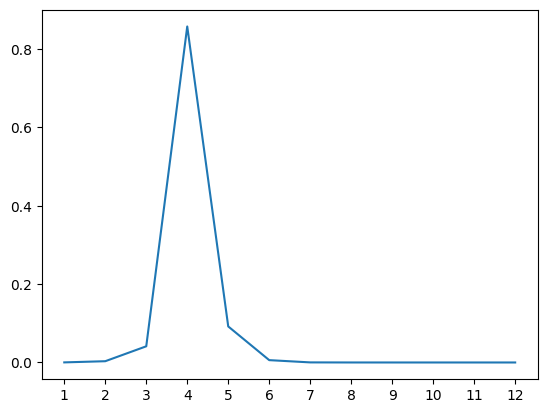

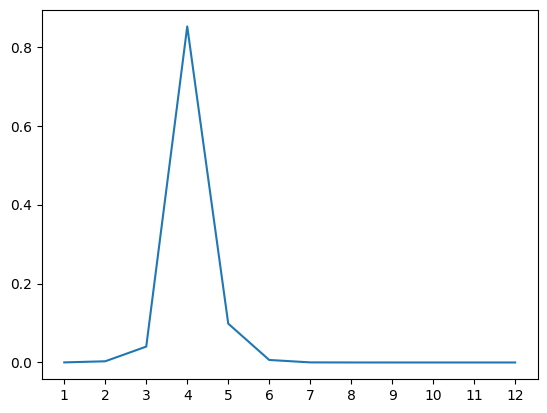

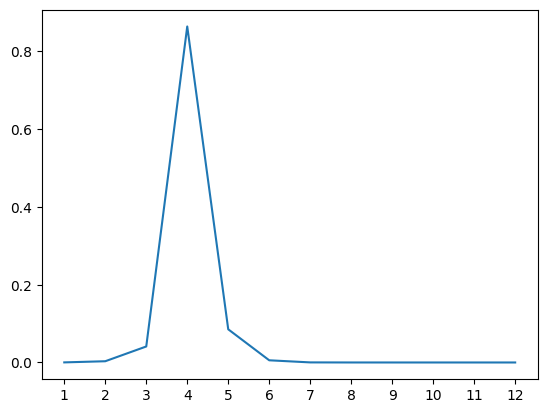

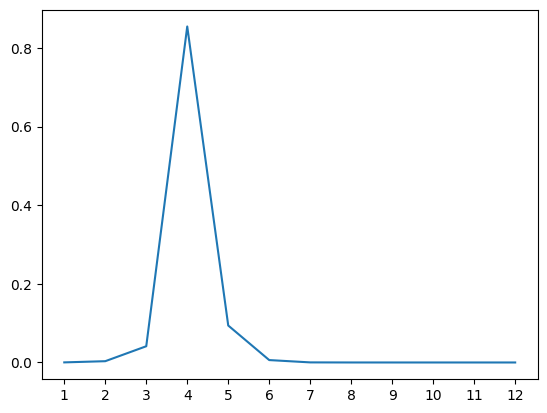

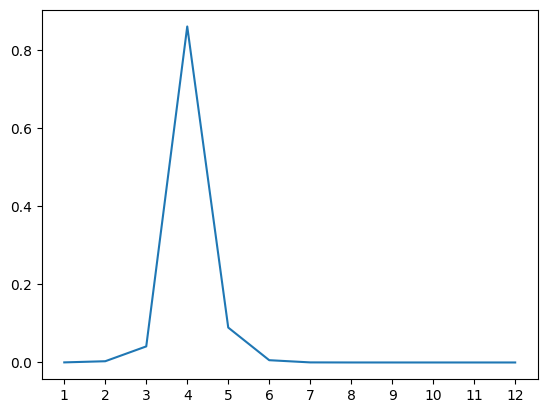

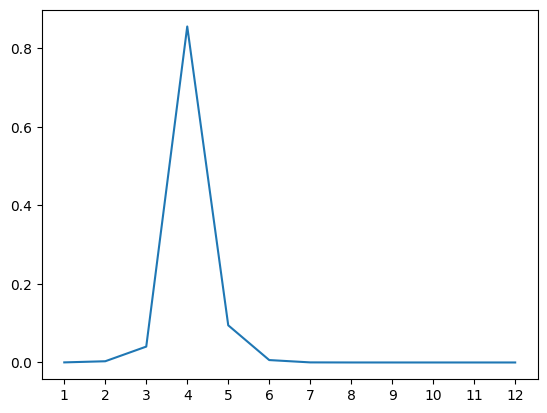

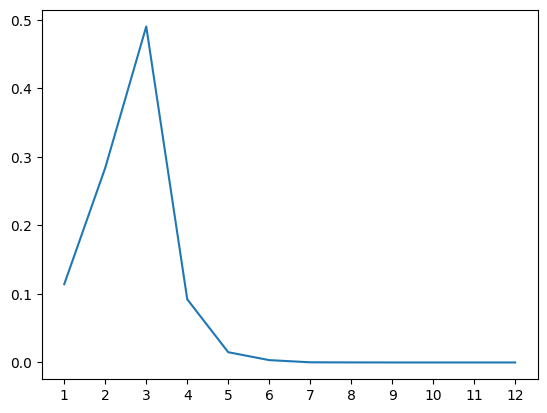

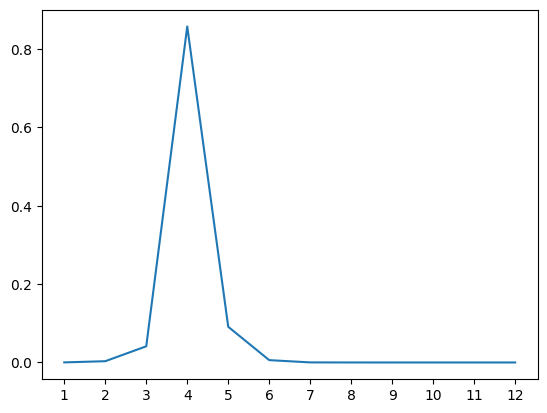

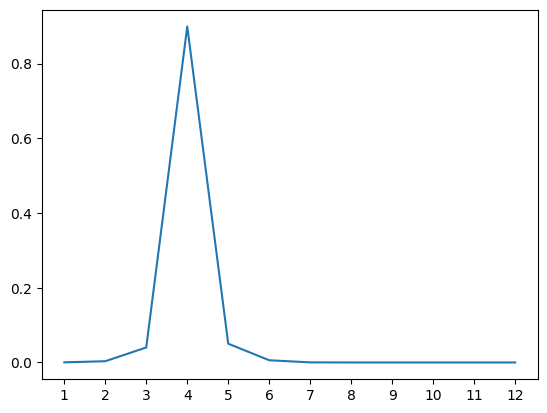

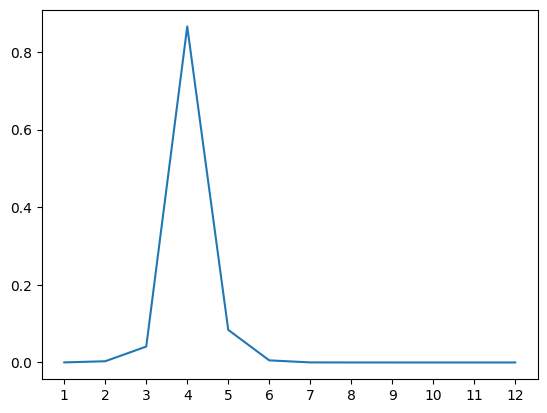

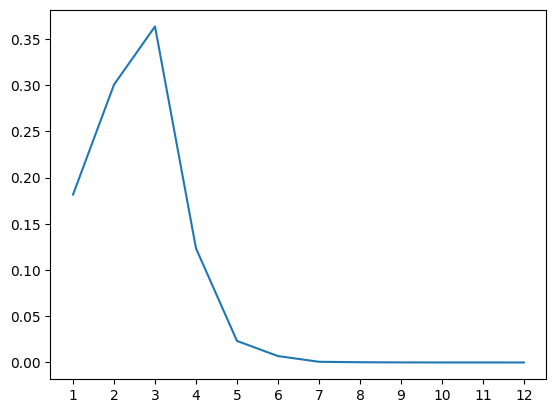

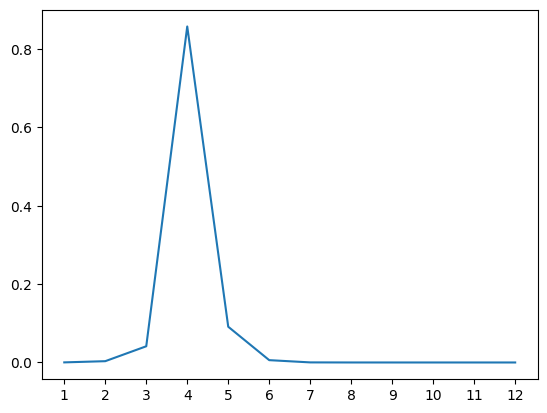

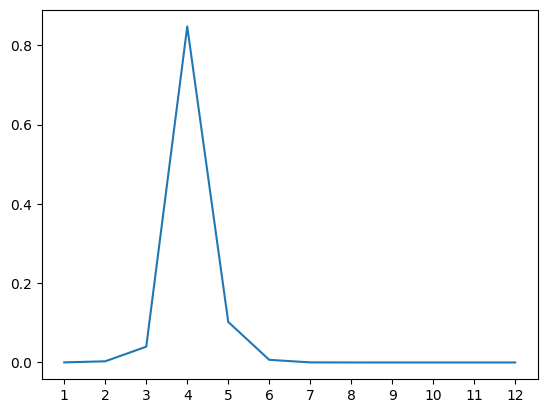

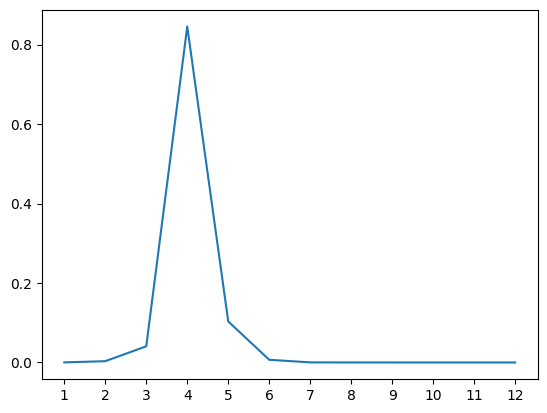

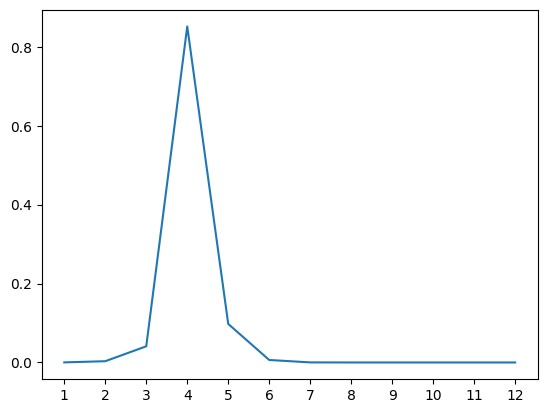

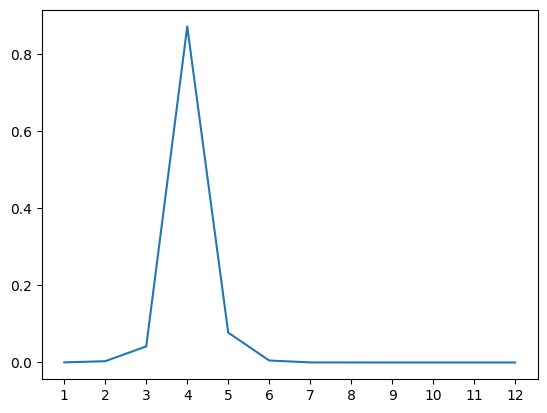

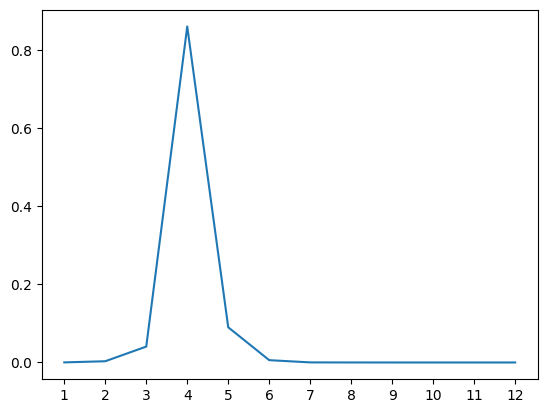

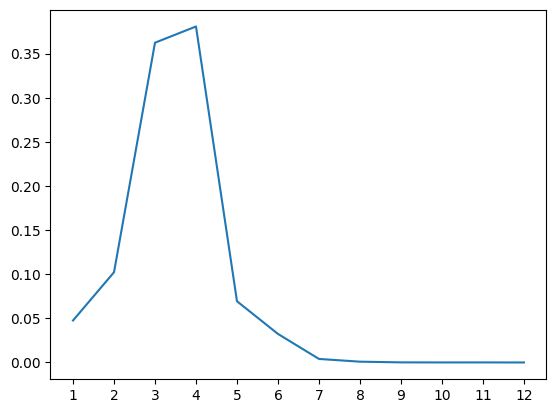

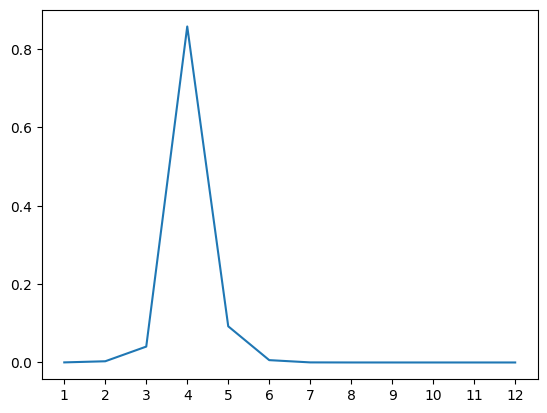

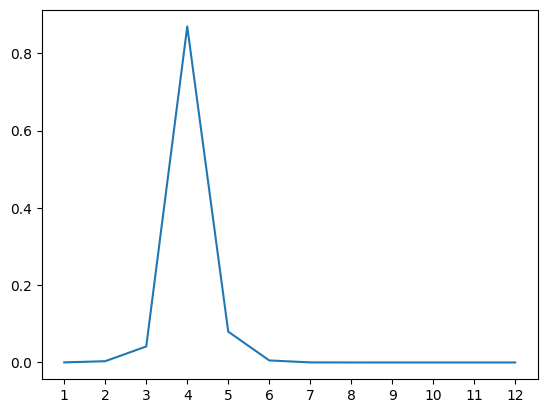

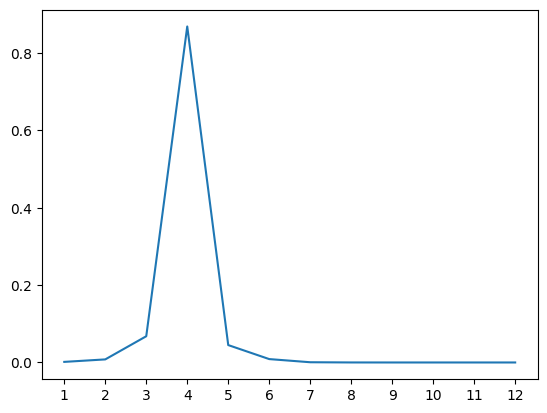

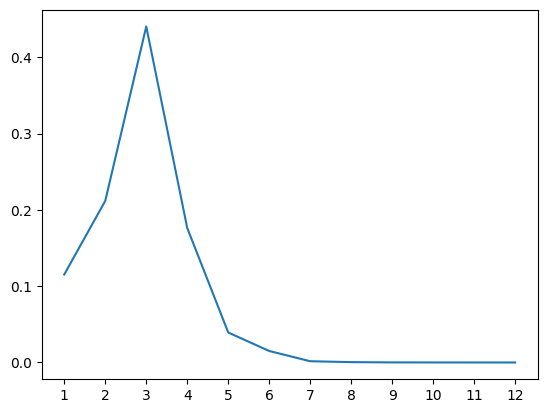

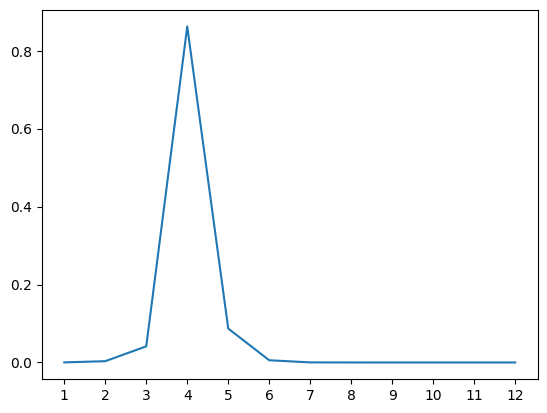

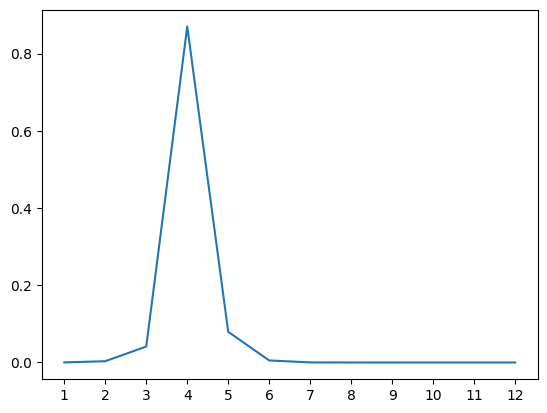

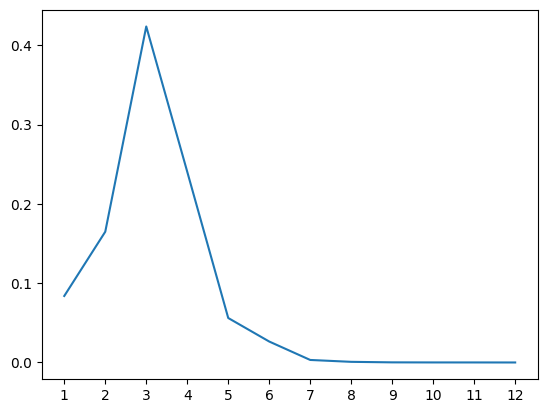

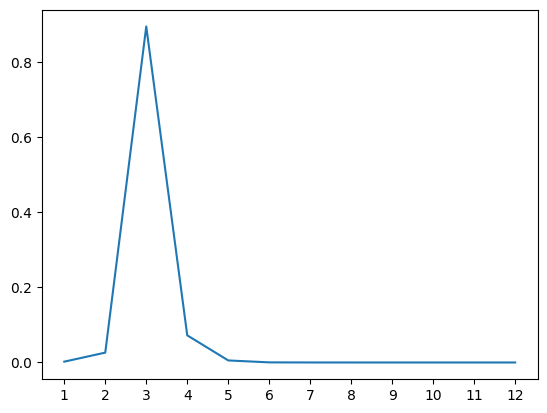

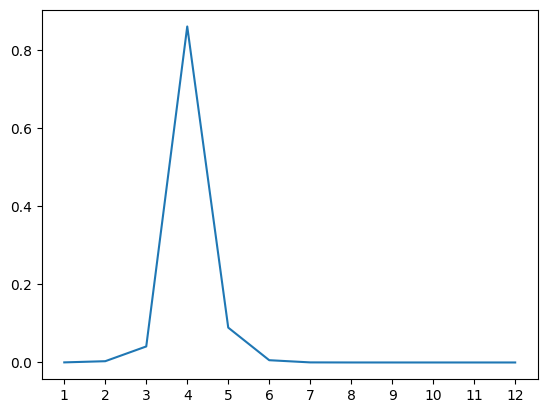

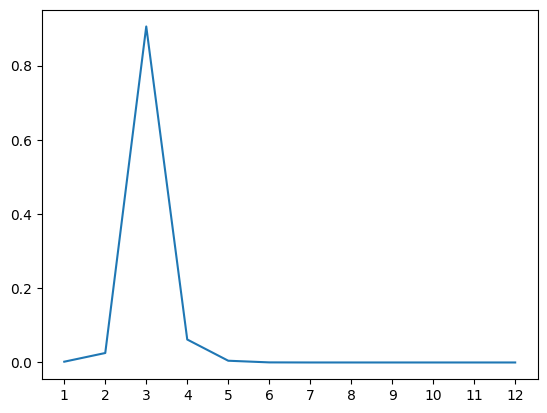

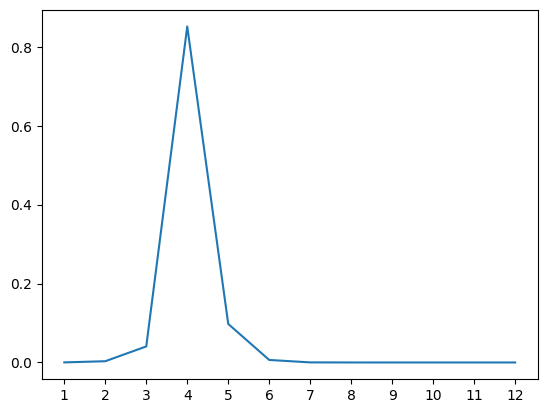

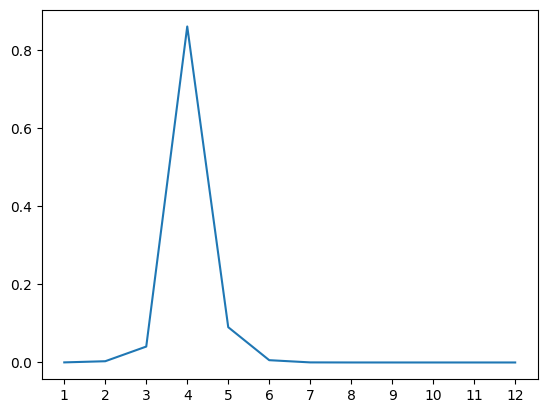

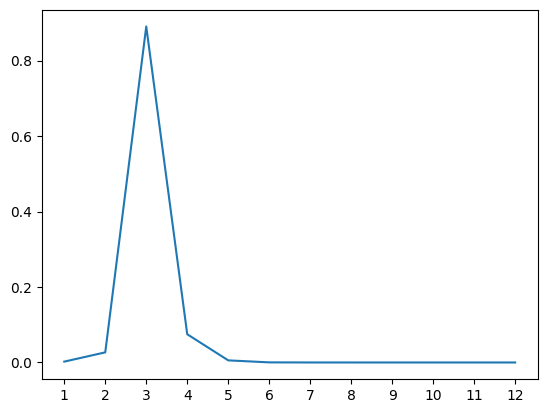

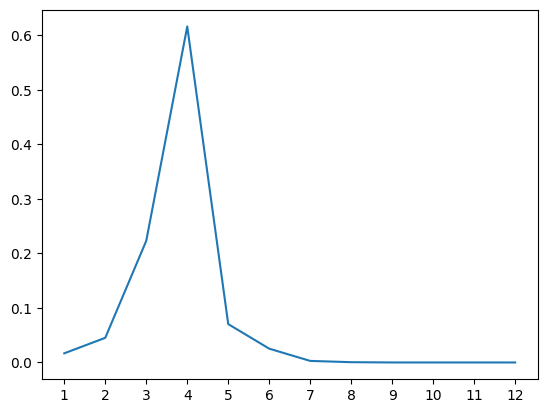

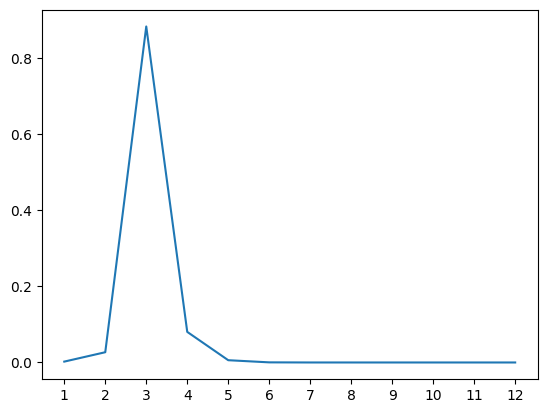

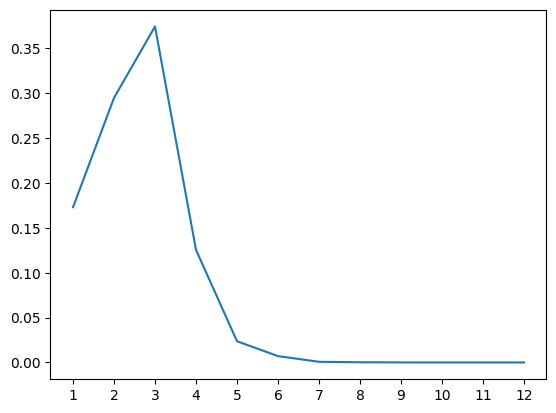

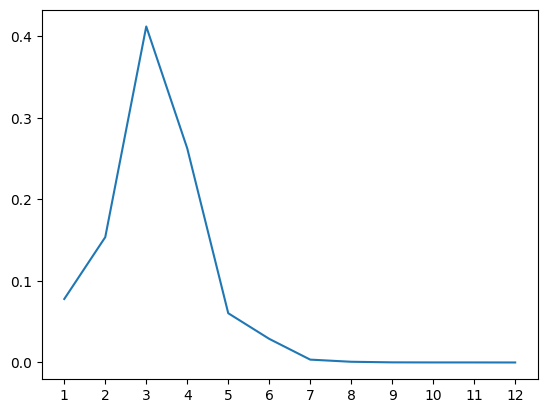

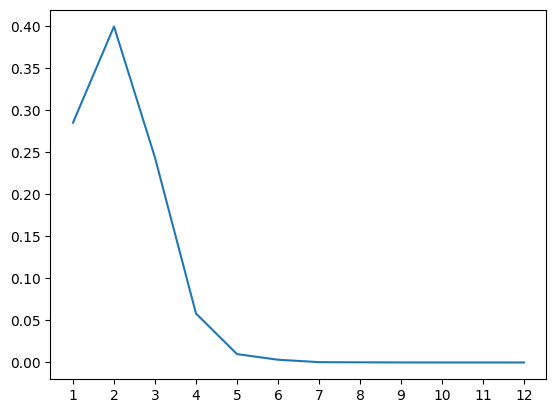

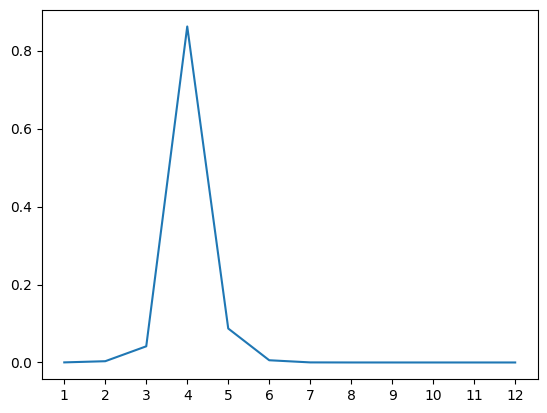

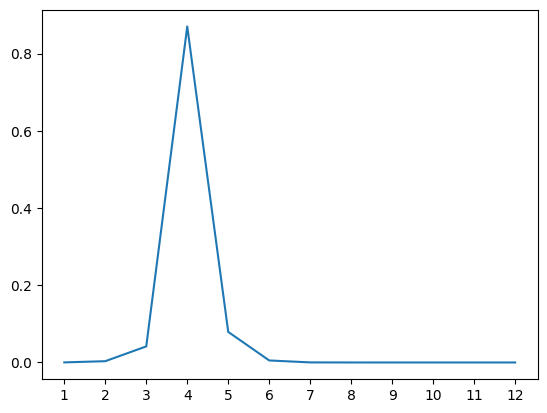

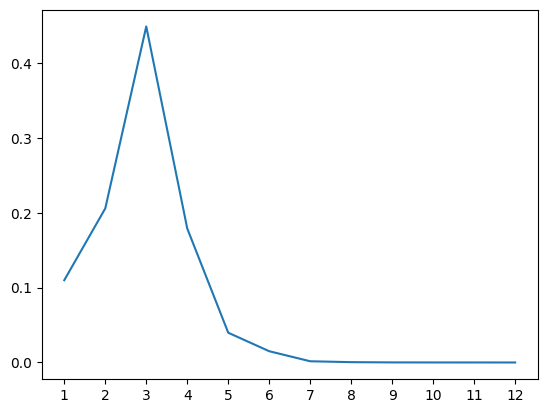

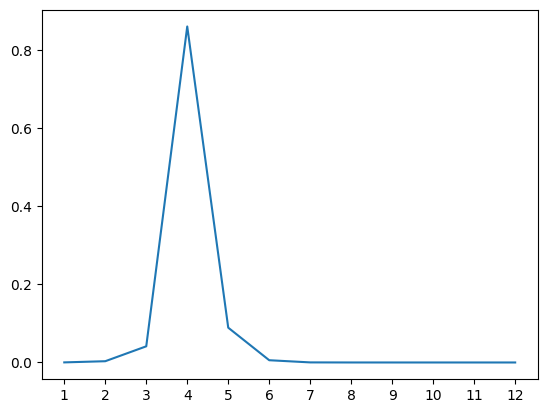

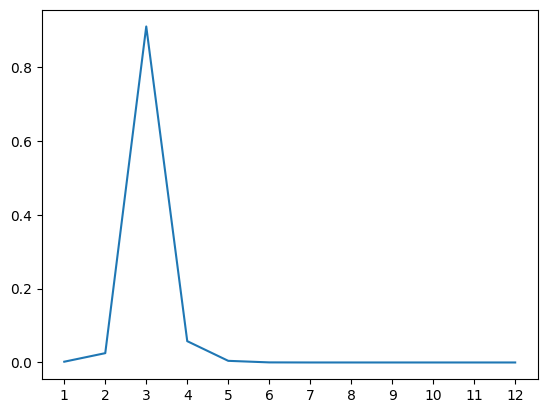

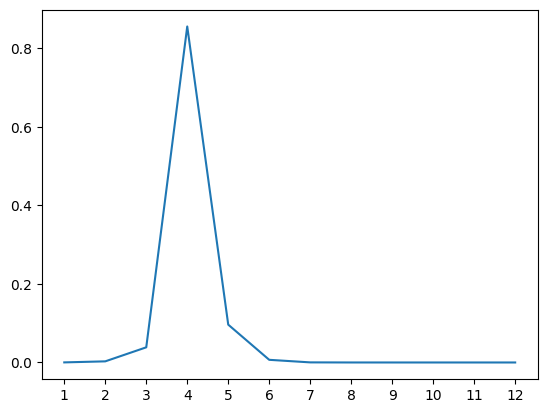

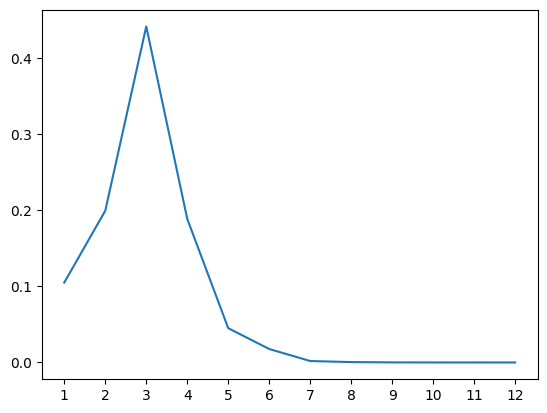

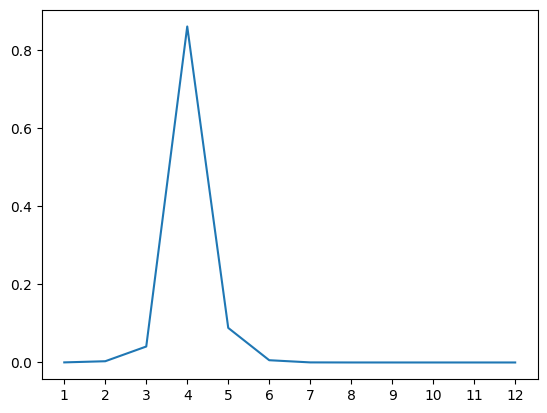

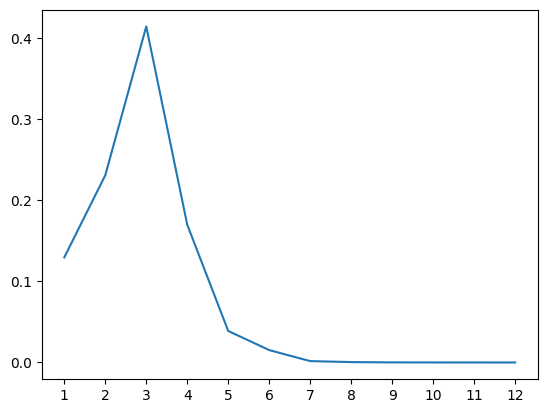

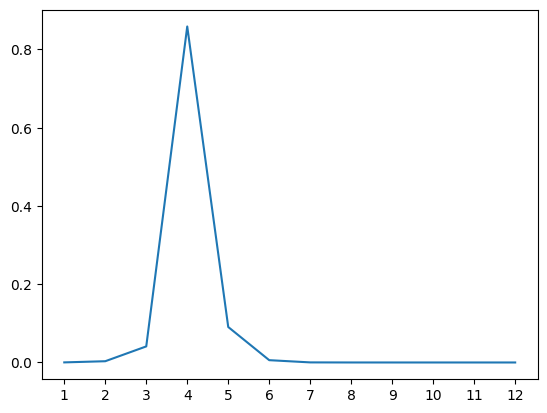

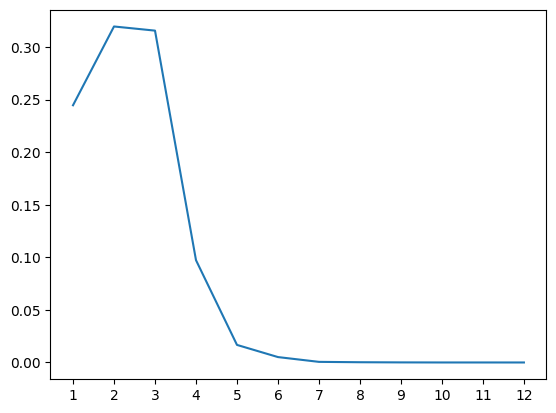

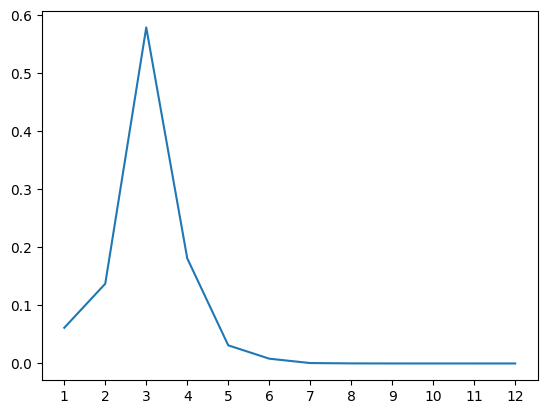

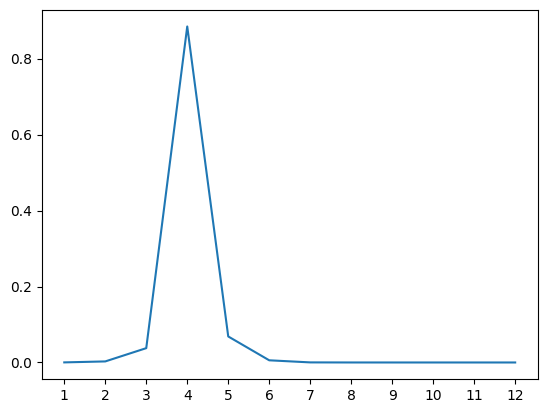

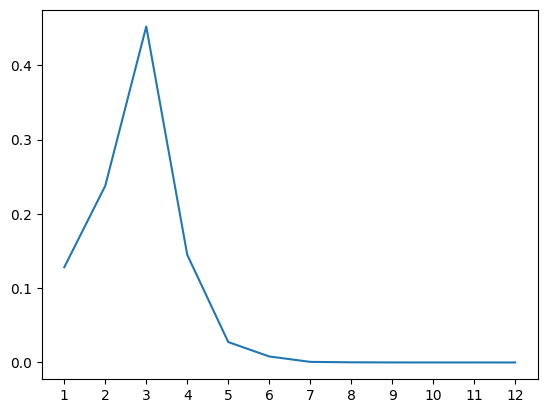

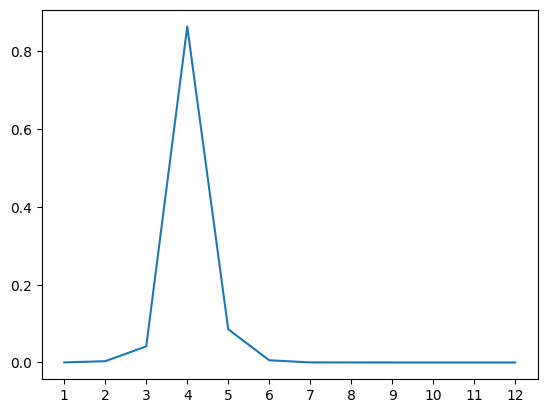

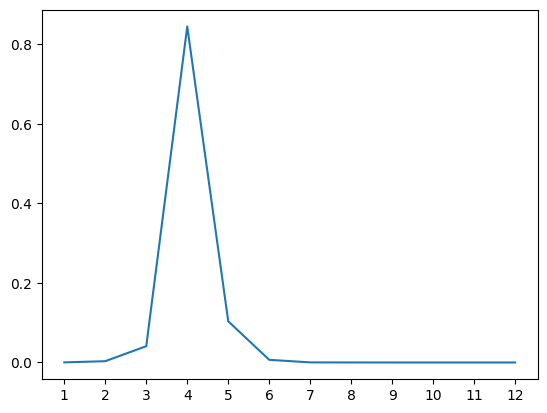

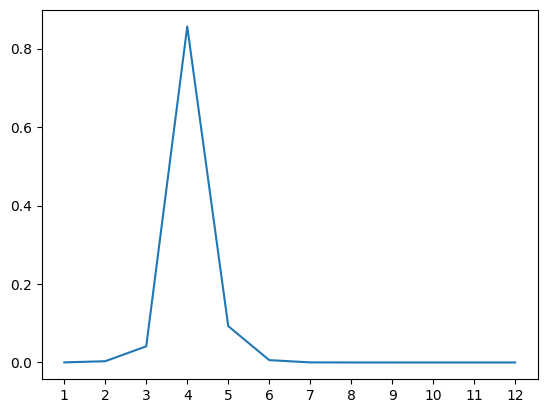

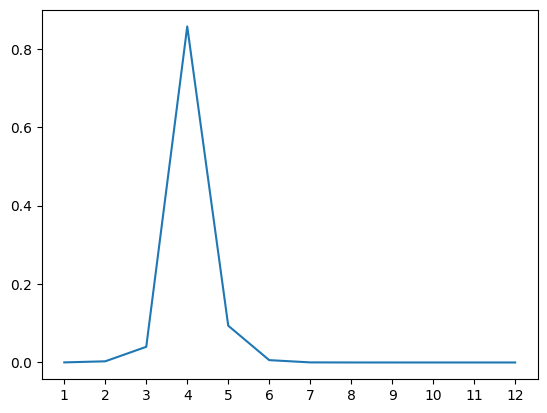

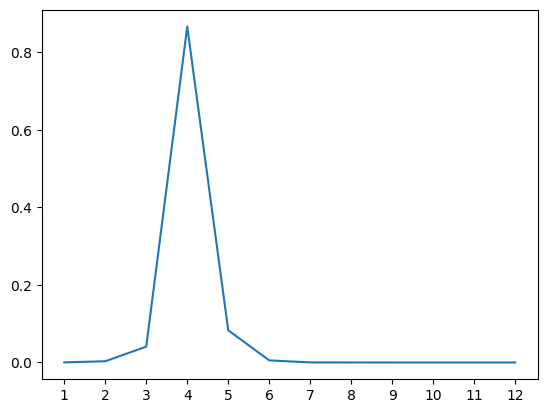

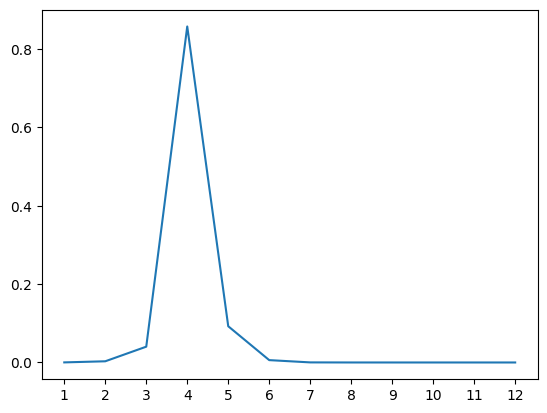

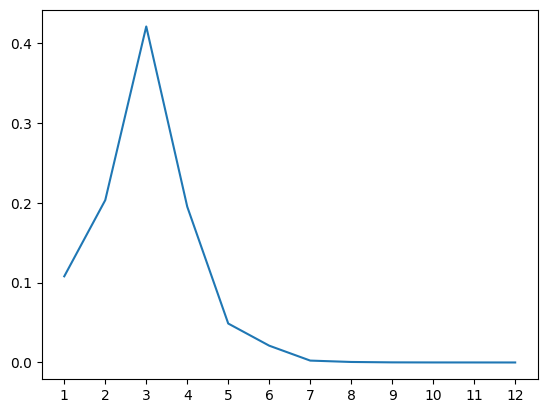

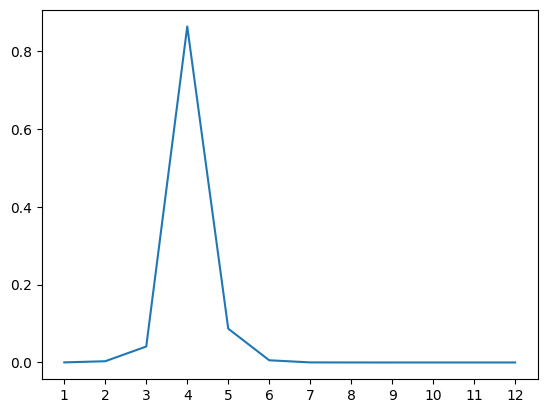

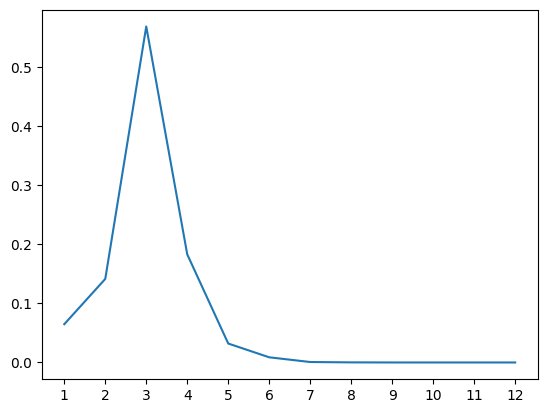

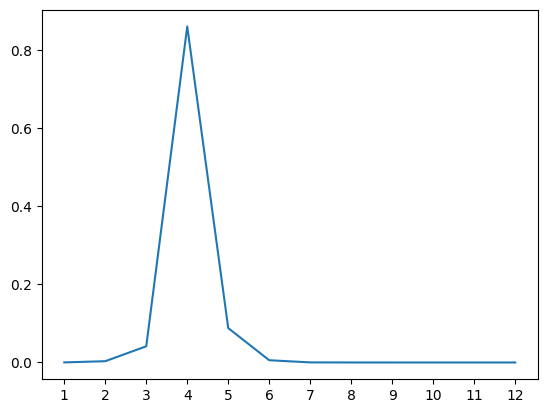

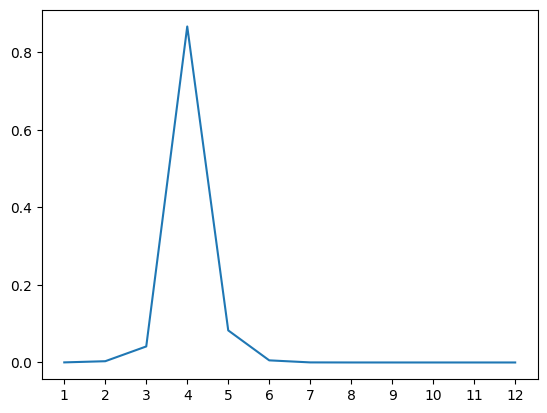

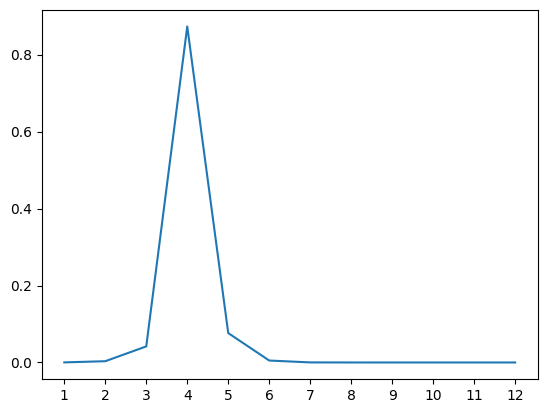

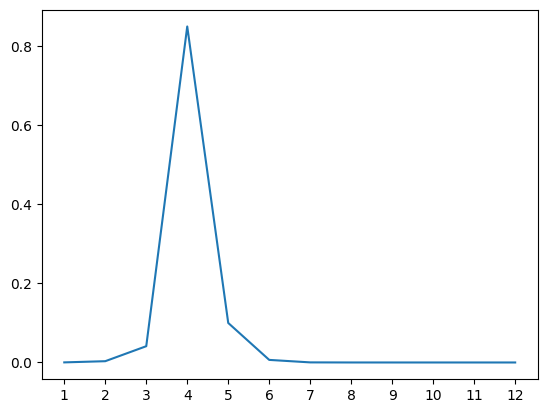

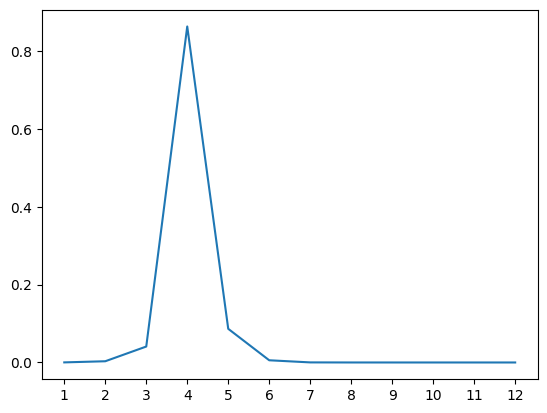

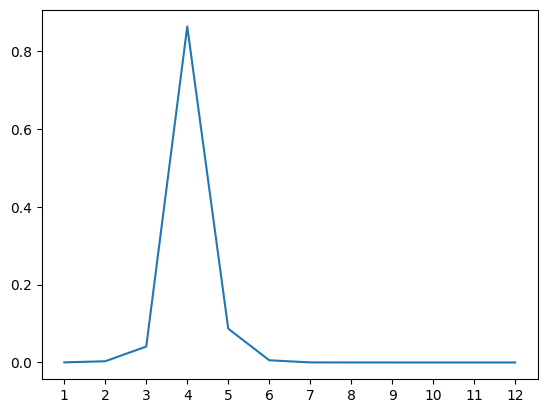

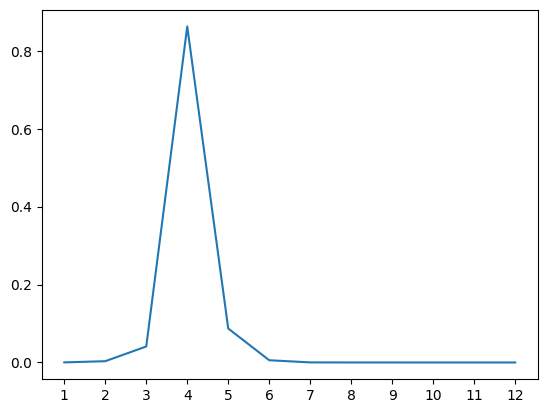

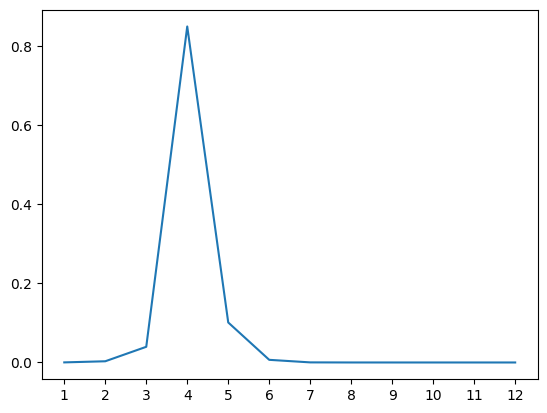

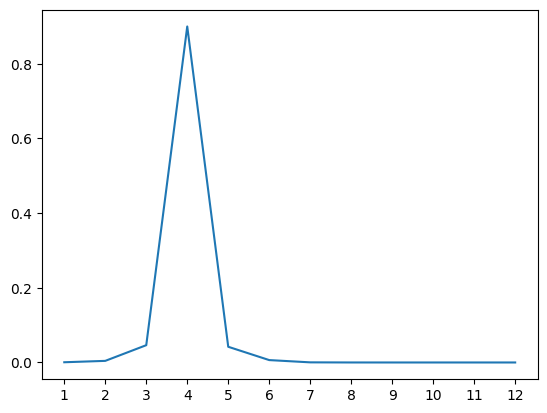

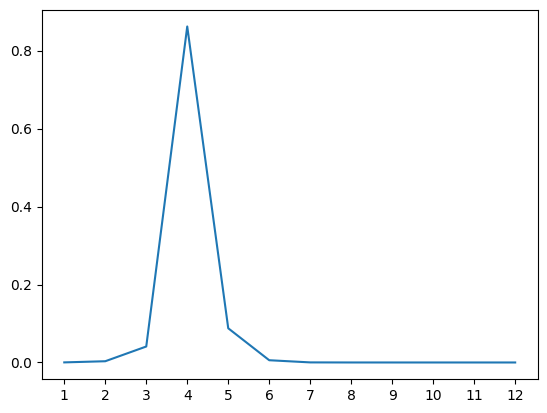

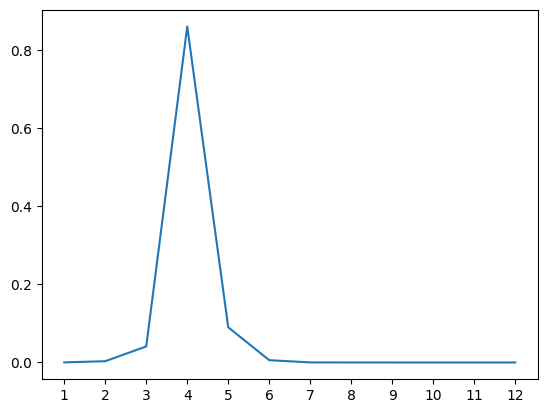

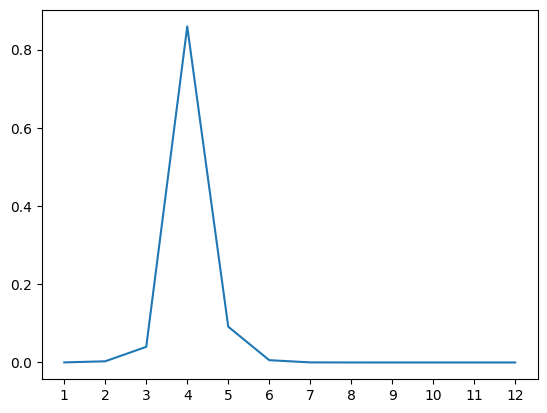

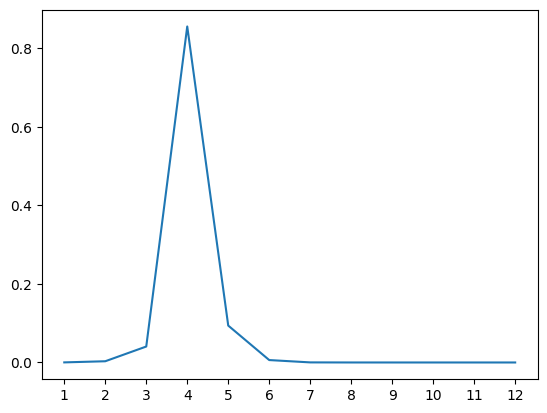

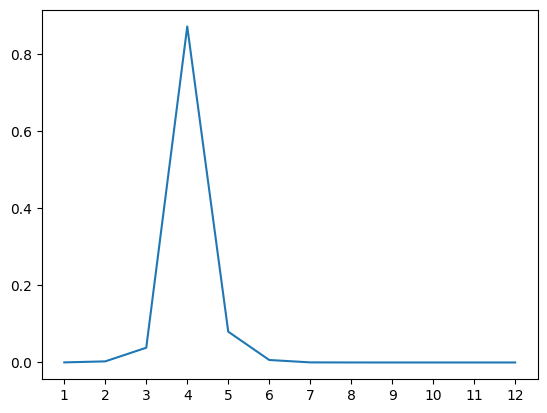

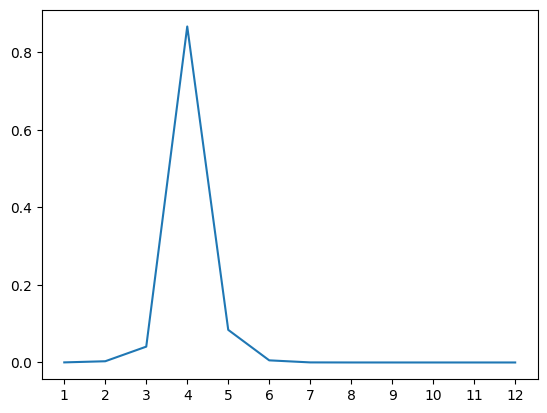

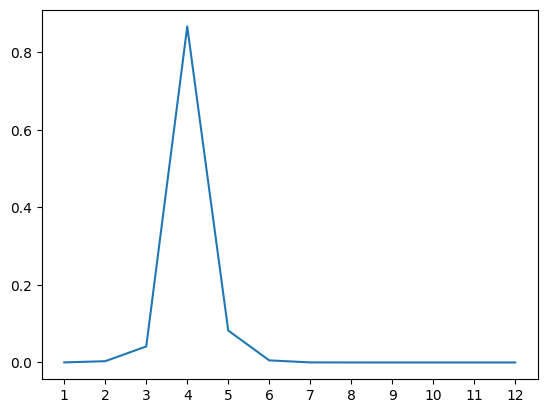

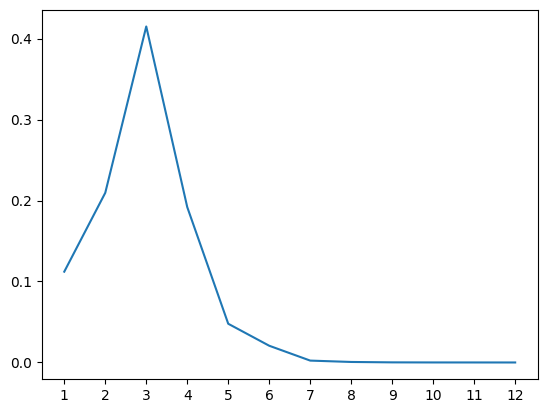

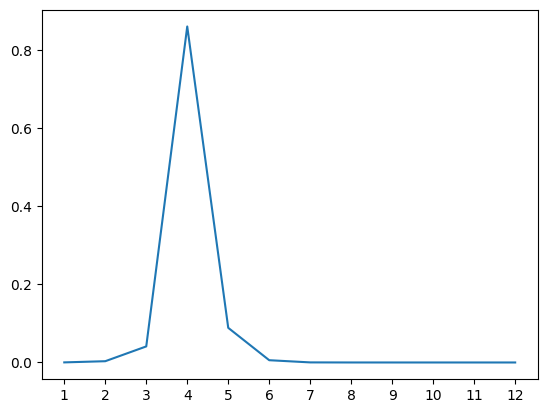

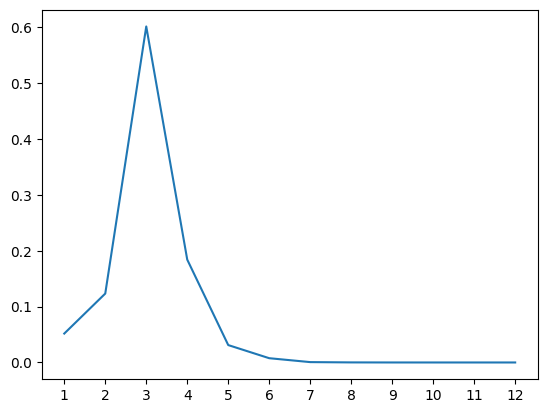

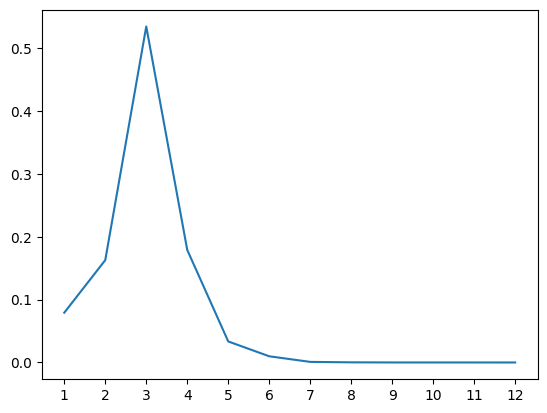

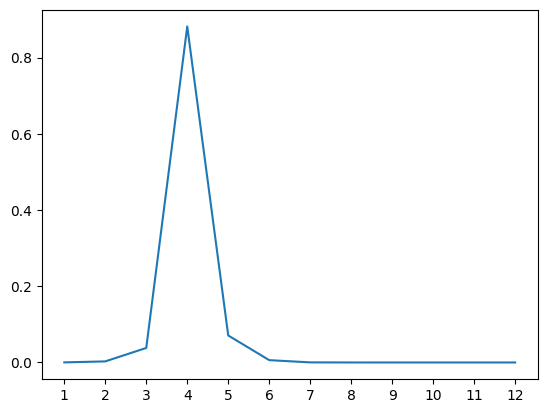

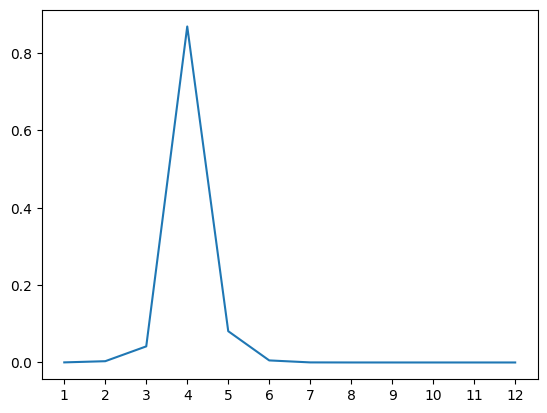

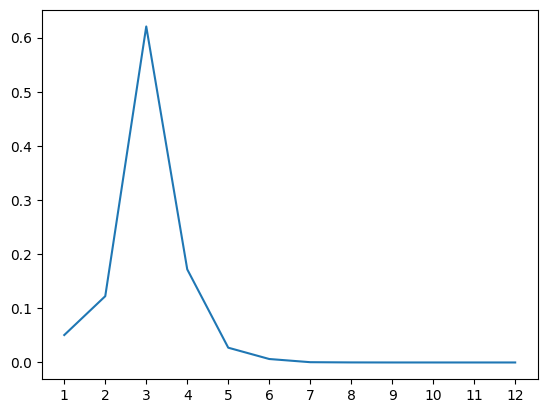

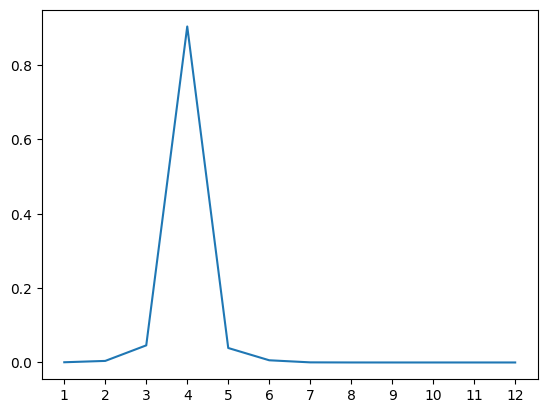

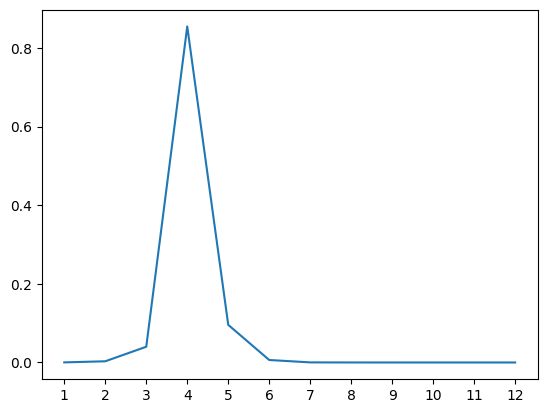

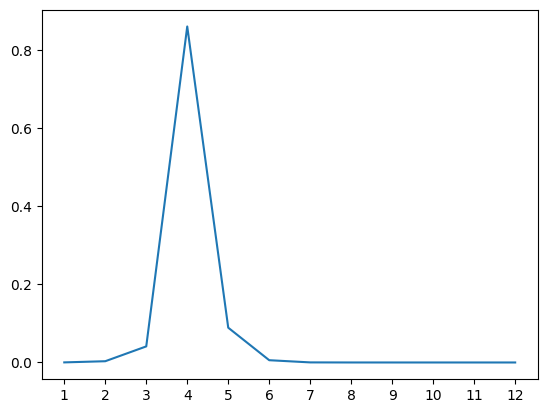

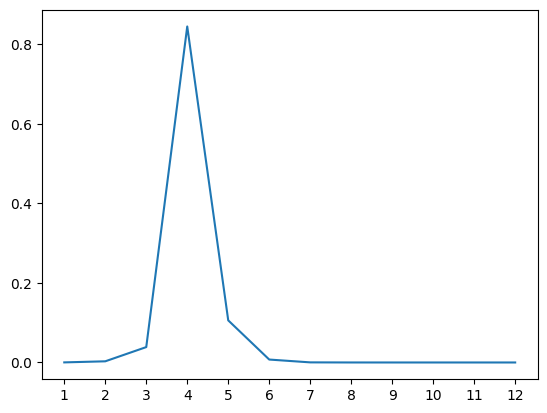

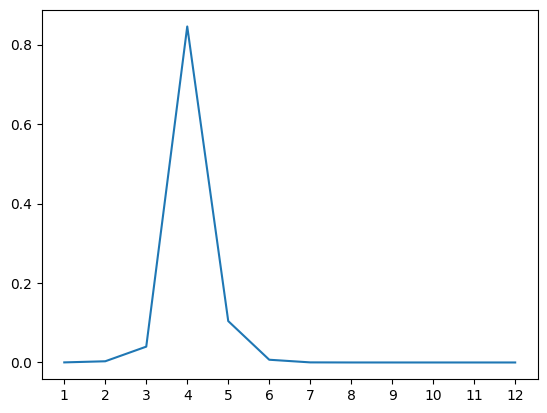

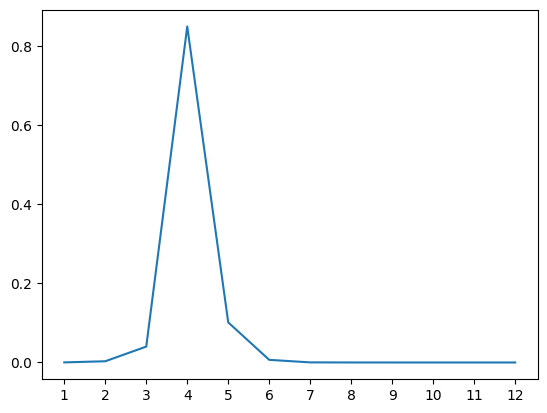

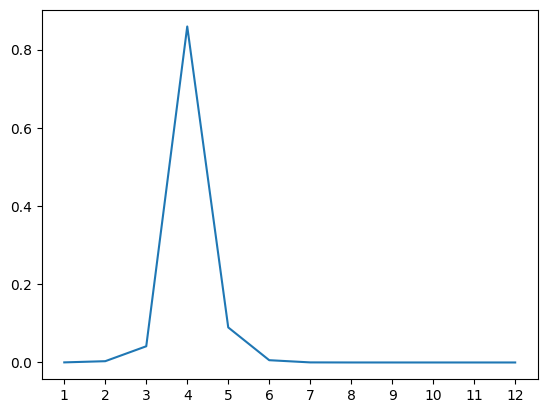

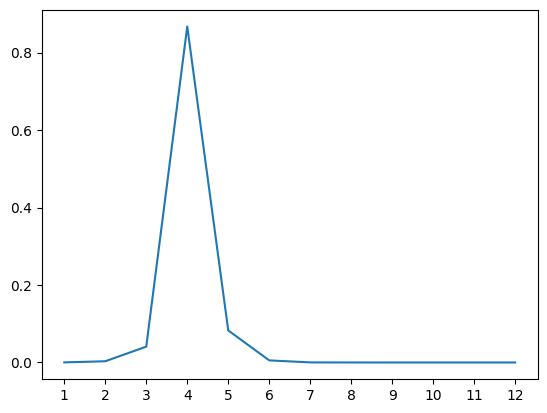

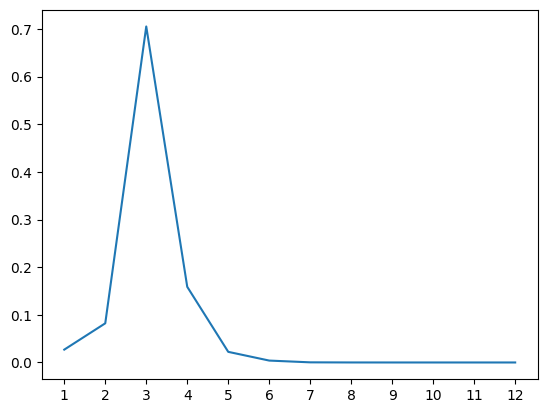

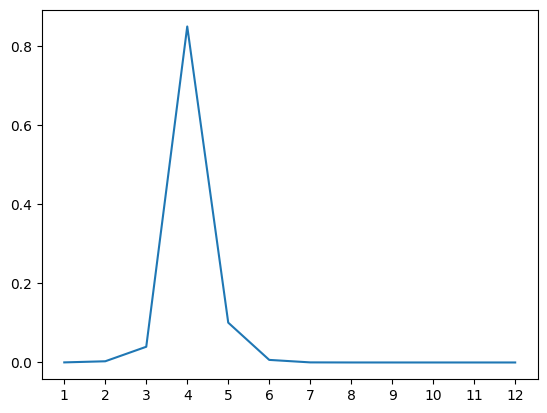

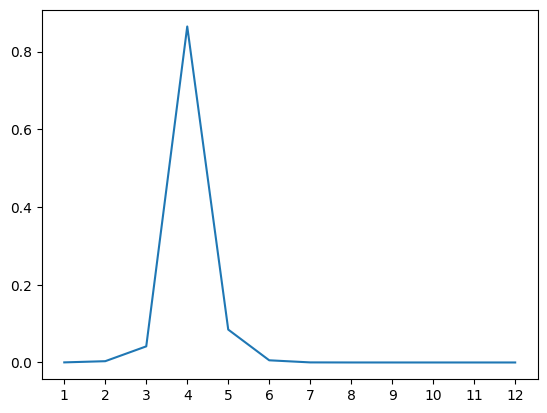

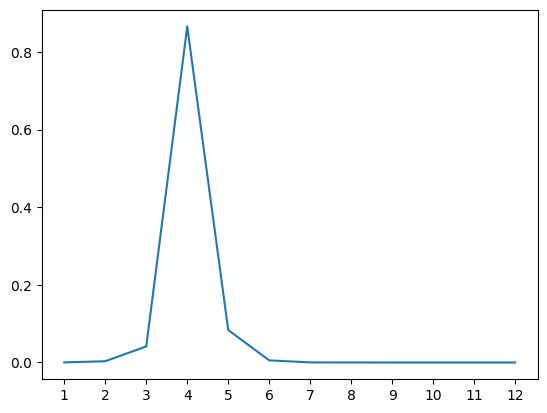

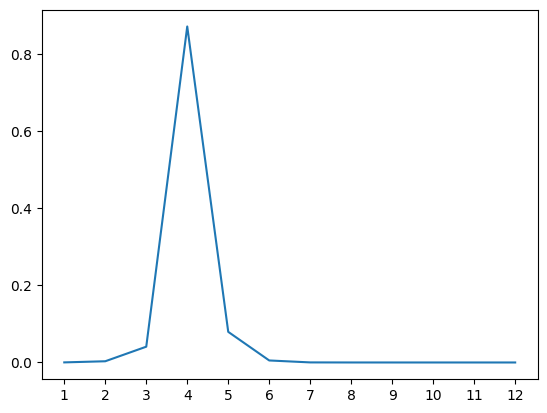

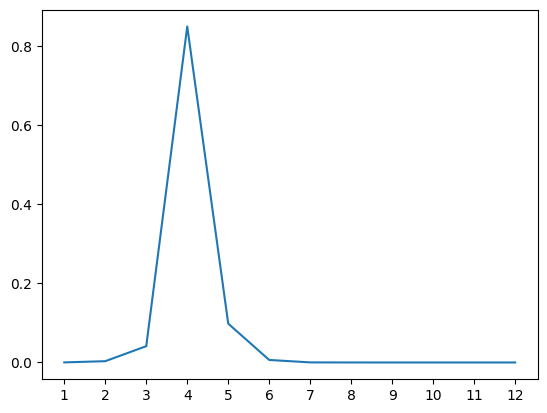

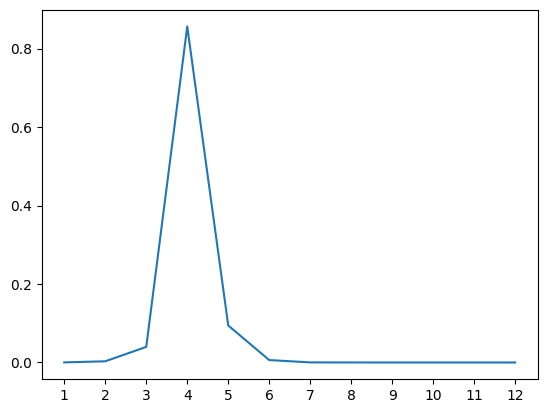

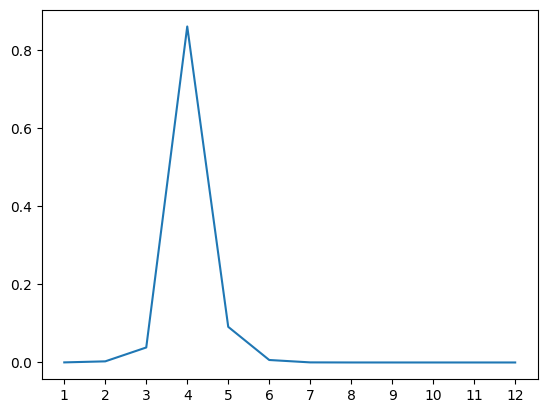

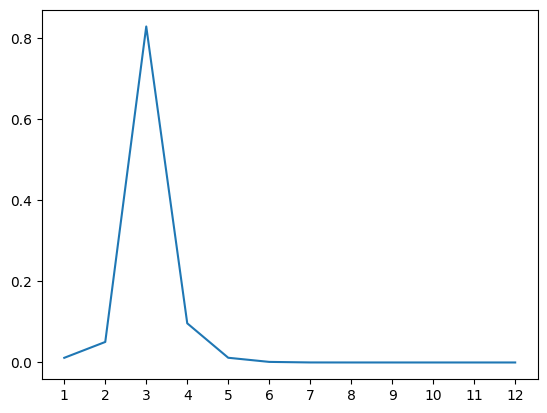

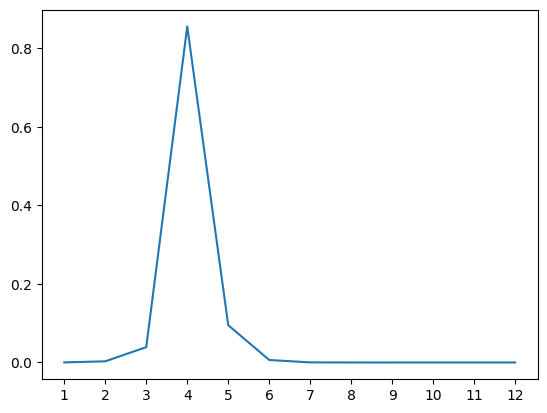

In [77]:
results = []
for i in range(100):
    results.append(run_test(0))

In [78]:
results = np.array(results)

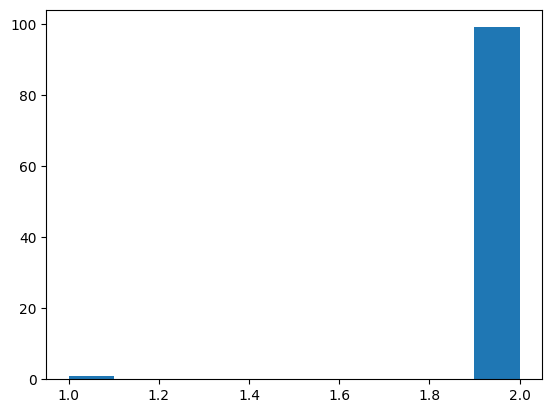

In [79]:
plt.hist(results[:,0])
plt.show()

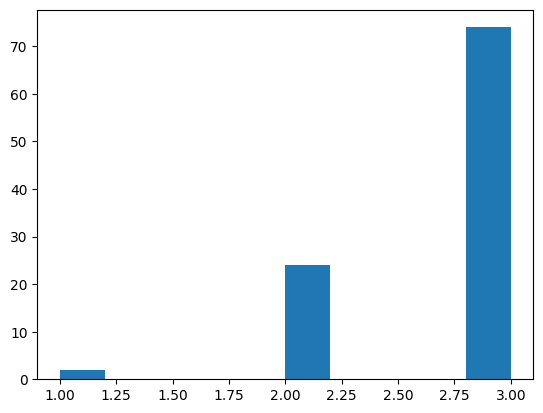

In [80]:
plt.hist(results[:,1])
plt.show()

In [81]:
np.sum(results[:,1] == 3)

np.int64(74)

In [82]:
np.sum(results[:,1] == 2)

np.int64(24)

In [38]:
T1 = np.zeros((4,4))
T1[:2,0] = np.random.randn(2)
T1[:2,2] = np.random.randn(2)

H1 = np.zeros((4,4))
H1[0,0], H1[1,1], H1[3,2], H1[2,3] = 1, 1, 1, 1

K1 = np.zeros((4,4)) + np.diag(np.ones(2), k=2) + np.diag(np.ones(2), k=-2)

T1_star = H1 @ T1.T @ K1



In [39]:
_ = test_matrix(T1_star @ T1) # 2
_ = test_matrix(T1 @ T1_star) # 1 

In [40]:
H2 = np.zeros((8,8))
H2[:4, :4] = H1
H2[4:6, 6:8] = np.eye(2)
H2[6:8, 4:6] = np.eye(2)

K2 = np.zeros((8,8))
K2[:4, :4] = K1
K2[4:6, 6:8] = np.eye(2)
K2[6:8, 4:6] = np.eye(2)

In [41]:
T2 = np.zeros((8,8))
T2[:4,:4] = T1
T2[:4,5:7] = np.random.randn(4,2)
T2[5:7,:4] = np.random.randn(2,4)
T2[5:7,5:7] = np.random.randn(2,2)

T2_star = H2 @ T2.T @ K2

In [42]:
TTstar = np.zeros((9,9))
TTstar[:8,:8] = T2 @ T2_star

TstarT = np.zeros((9,9))
TstarT[:8,:8] = T2_star @ T2

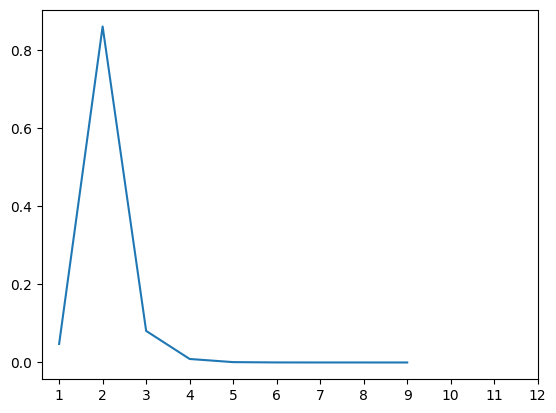

In [43]:
p = test_matrix(TTstar)
plt.plot(p.detach().numpy()[0])
plt.xticks(ticks=range(12), labels=range(1, 13))
plt.show()

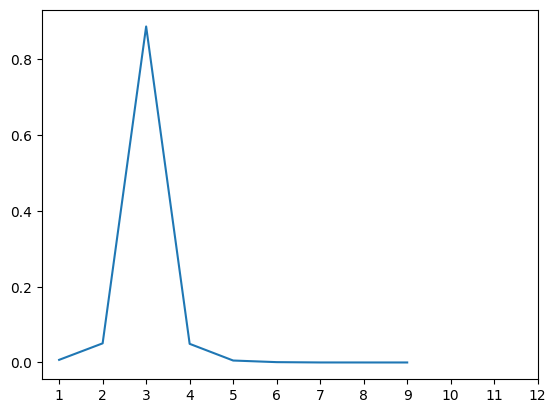

In [44]:
p = test_matrix(TstarT)
plt.plot(p.detach().numpy()[0])
plt.xticks(ticks=range(12), labels=range(1, 13))
plt.show()

In [46]:
H3 = np.zeros((13,13))
H3[:8,:8] = H2
H3[8, 8] = 1
H3[9:11, 11:] = np.eye(2)
H3[11:, 9:11] = np.eye(2)

K3 = np.zeros((12,12))
K3[:8,:8] = K2
K3[8:10, 10:] = np.eye(2)
K3[10:, 8:10] = np.eye(2)

T3 = np.zeros((12, 13))
T3[:8, :8] = T2
T3[:8, 9:11] = np.random.randn(8,2)
T3[8:10, :8] = np.random.randn(2,8)
T3[8:10, 9:11] = np.random.randn(2,2)

T3_star = H3 @ T3.T @ K3

In [47]:
probs1 = test_matrix(T3_star @ T3) # 3
probs2 = test_matrix(T3 @ T3_star) # 4

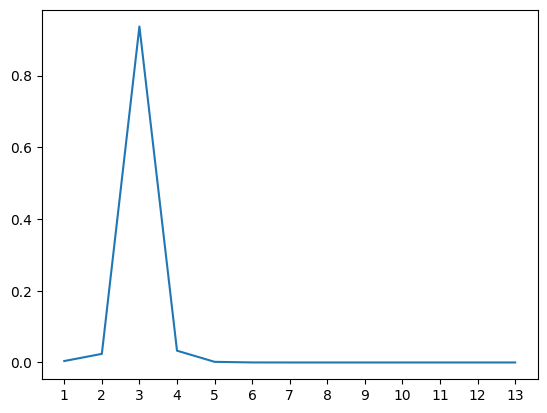

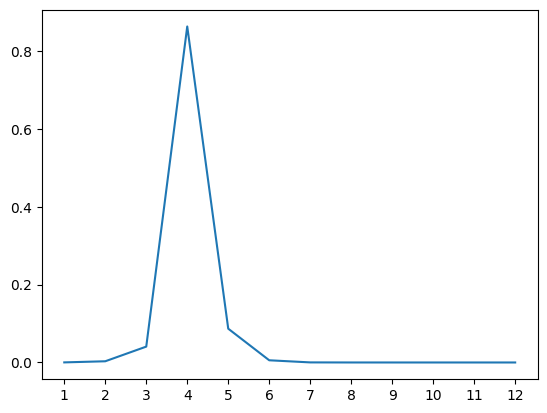

In [48]:
plt.plot(probs1.detach().numpy()[0])
plt.xticks(ticks=range(13), labels=range(1, 14))
plt.show()
plt.plot(probs2.detach().numpy()[0])
plt.xticks(ticks=range(12), labels=range(1, 13))
plt.show()

# 2.

In [3]:
import pandas as pd

In [4]:
np.random.seed(123)

In [ ]:
def naive_classifier(A, eps): 
    k = 1
    d = A.shape[0]
    A_pow = np.eye(d)
    rk_prev = d
    while k < d:
        A_pow = A_pow @ A
        rk = np.linalg.matrix_rank(A_pow, rtol=eps*d if eps > 0 else None)
        # print(k, rk)
        if rk == 0 or rk > rk_prev:
            return k
        else:
            rk_prev = rk
            k += 1
    return k

In [6]:
d = 28 
naive_results = []
for m in range(1, d+1):
    for _ in range(1000):
        if np.random.uniform(0, 1) < 0.1:
            eps = 0.0
        else:
            eps = np.exp(np.random.uniform(np.log(1e-8), np.log(0.1)))

        A, rad, E_norm, _ = generate_matrix(d, m, 'random', eps)
        if rad > 1:
            rad /= rad
            A /= rad
            E_norm /= rad
        pred = naive_classifier(A, eps)
        res = {
            "true_class": m,
            "pred_class": pred,
            "rad": rad,
            "E_norm": E_norm,
        }
        naive_results.append(res)

naive_results = pd.DataFrame(naive_results)

In [7]:
naive_results.describe()

,true_class,pred_class,rad,E_norm
count,28000.000000,28000.000000,28000.000000,2.800000e+04
mean,14.500000,14.175179,0.379412,1.075115e-02
std,8.077891,9.748074,0.277169,3.005014e-02
min,1.000000,1.000000,0.000000,0.000000e+00
25%,7.750000,5.000000,0.099136,2.841035e-07
50%,14.500000,13.000000,0.402540,2.511984e-05
75%,21.250000,24.000000,0.599529,2.217373e-03
max,28.000000,28.000000,0.973501,2.054990e-01


In [8]:
def load_results_csvs(folder_path):
    """
    Reads all CSV files named results_{d}.csv (d = 1 or 2 digits)
    from the given folder and returns a dict of DataFrames.

    Returns:
        dict[int, pd.DataFrame]: {d: dataframe}
    """
    pattern = re.compile(r"^results_(\d{1,2})\.csv$")
    data = {}

    for filename in os.listdir(folder_path):
        match = pattern.match(filename)
        if match:
            d = int(match.group(1))
            file_path = os.path.join(folder_path, filename)
            df = pd.read_csv(file_path)
            data[d] = df

    return data

nn_results = load_results_csvs("./sandbox/jordan8_results")[28]

In [9]:
naive_results.head()

,true_class,pred_class,rad,E_norm
0,1,28,9.807902e-07,0.000002
1,1,2,2.665640e-04,0.000468
2,1,1,3.791669e-02,0.069762
3,1,4,1.866456e-03,0.003238
4,1,1,0.000000e+00,0.000000


In [10]:
nn_results = nn_results[nn_results["E_norm"]<= 0.1]
naive_results = naive_results[naive_results["E_norm"]<= 0.1]

In [11]:
naive_results.describe()

,true_class,pred_class,rad,E_norm
count,26968.000000,26968.000000,26968.000000,2.696800e+04
mean,14.501520,14.679361,0.366352,5.847060e-03
std,8.067828,9.579370,0.269924,1.604801e-02
min,1.000000,1.000000,0.000000,0.000000e+00
25%,8.000000,5.000000,0.088473,2.375620e-07
50%,15.000000,14.000000,0.389111,1.797684e-05
75%,21.000000,25.000000,0.584158,1.328623e-03
max,28.000000,28.000000,0.931484,9.990968e-02


In [12]:
nn_results.describe()

,true_class,pred_class,kl_loss,E_norm,S_cond,rad
count,268587.000000,268587.000000,2.685870e+05,268587.000000,268587.000000,268587.000000
mean,13.538362,13.524281,3.547960e-02,0.006725,249.297761,0.392780
std,8.082710,8.066276,1.084320e-01,0.017003,505.938966,0.257256
min,0.000000,0.000000,4.114084e-07,0.000000,12.724568,0.000000
25%,7.000000,7.000000,3.776551e-03,0.000002,56.800833,0.163235
50%,14.000000,14.000000,9.838291e-03,0.000065,98.932879,0.420002
75%,21.000000,21.000000,2.352546e-02,0.002493,209.021744,0.592519
max,27.000000,27.000000,1.230545e+01,0.099991,5599.826951,0.950434


In [ ]:

def plot_acc_vs_metric(
    ax,
    df,
    metric="E_norm",
    bins=None,
    k=1,
    s="Model",
    color="tab:blue",
    marker=None,
):
    required = {"true_class", "pred_class", metric}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    data = df[["true_class", "pred_class", metric]].dropna().copy()

    # ----------------------------
    # DEFAULT BIN STRUCTURE
    # ----------------------------
    if bins is None:
        bins = np.r_[0, np.logspace(-10, -1, 10)]

    bins = np.asarray(bins)

    # ensure sorted
    bins = np.unique(bins)
    bins.sort()

    # ----------------------------
    # ASSIGN BINS
    # ----------------------------
    data["bin"] = pd.cut(
        data[metric],
        bins=bins,
        include_lowest=True,
        right=True,
    )

    data["acc"] = data["true_class"] == data["pred_class"]
    data["acc_k"] = np.abs(data["true_class"] - data["pred_class"]) <= k

    grouped = data.groupby("bin", observed=True)

    # ----------------------------
    # BIN CENTERS (IMPORTANT FIX)
    # ----------------------------
    left = grouped[metric].min()
    right = grouped[metric].max()

    # geometric mean for log bins, arithmetic for zero bin
    centers = []
    for l, r in zip(left, right):
        if l == 0 or np.isnan(l):
            centers.append(0)  # Directly at 0
        else:
            centers.append(np.sqrt(l * r))

    result = pd.DataFrame({
        "x": centers,
        "acc": grouped["acc"].mean().values,
        "acc_k": grouped["acc_k"].mean().values,
        "count": grouped.size().values,
    })

    # ----------------------------
    # PLOT
    # ----------------------------
    ax.plot(
        result["x"],
        result["acc"],
        linestyle="-",
        marker=marker,
        color=color,
        label=f"{s} (Acc)",
    )

    ax.plot(
        result["x"],
        result["acc_k"],
        linestyle=":",
        marker=marker,
        linewidth=2,
        color=color,
        label=f"{s} (Acc@$\\pm${k})",
    )
    return result

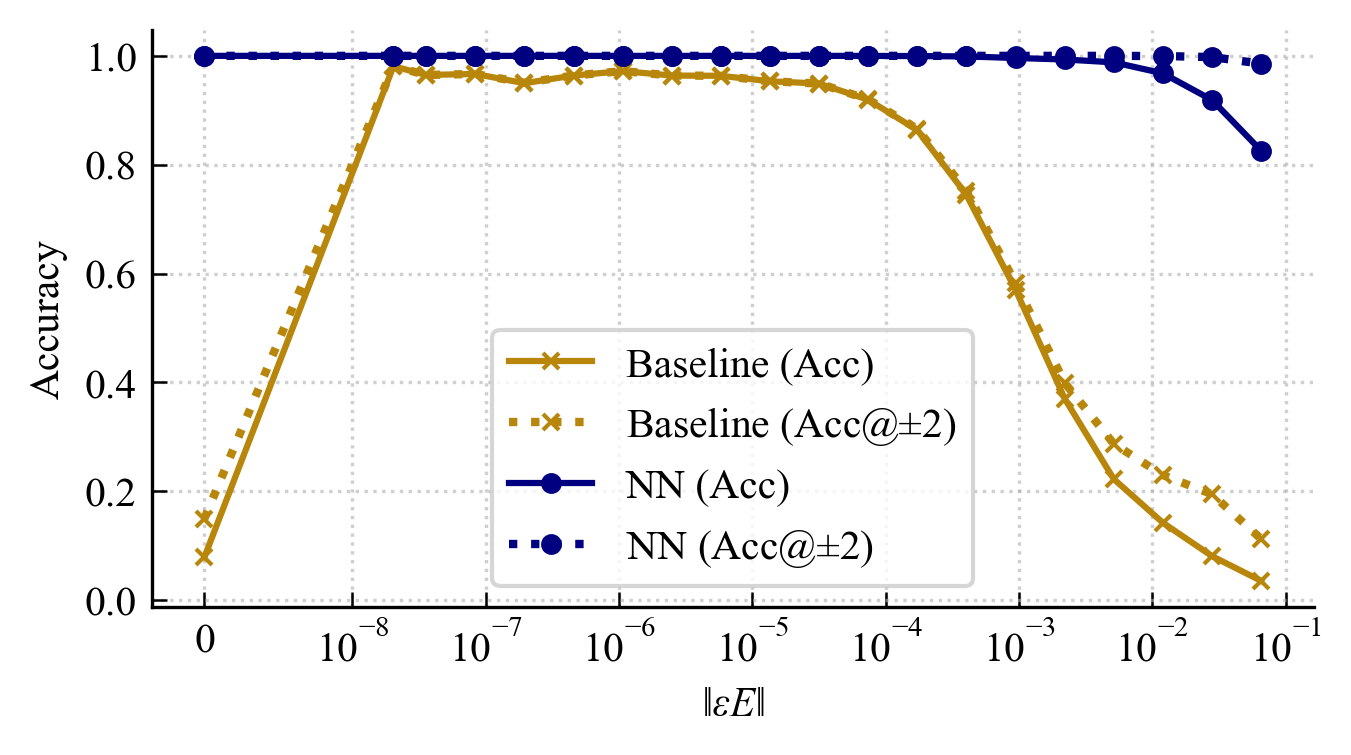

In [34]:
fig, ax = plt.subplots(figsize=(5, 2.5))

bins = np.r_[0, np.logspace(-8, -1, 20)]

plot_acc_vs_metric(
    ax=ax,
    df=naive_results,
    metric="E_norm",
    bins=bins,
    k=2,
    s="Baseline",
    color="darkgoldenrod",
    marker="x"
)

plot_acc_vs_metric(
    ax=ax,
    df=nn_results,
    metric="E_norm",
    bins=bins,
    k=2,
    s="NN",
    color="navy",
    marker="o"
)

ax.set_xscale("symlog", linthresh=1e-8)
ax.legend()
ax.set_xlabel("$\\|\\varepsilon E\\|$")
ax.set_ylabel("Accuracy")
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("latex/images/j8_naive_a.pdf")
plt.show()

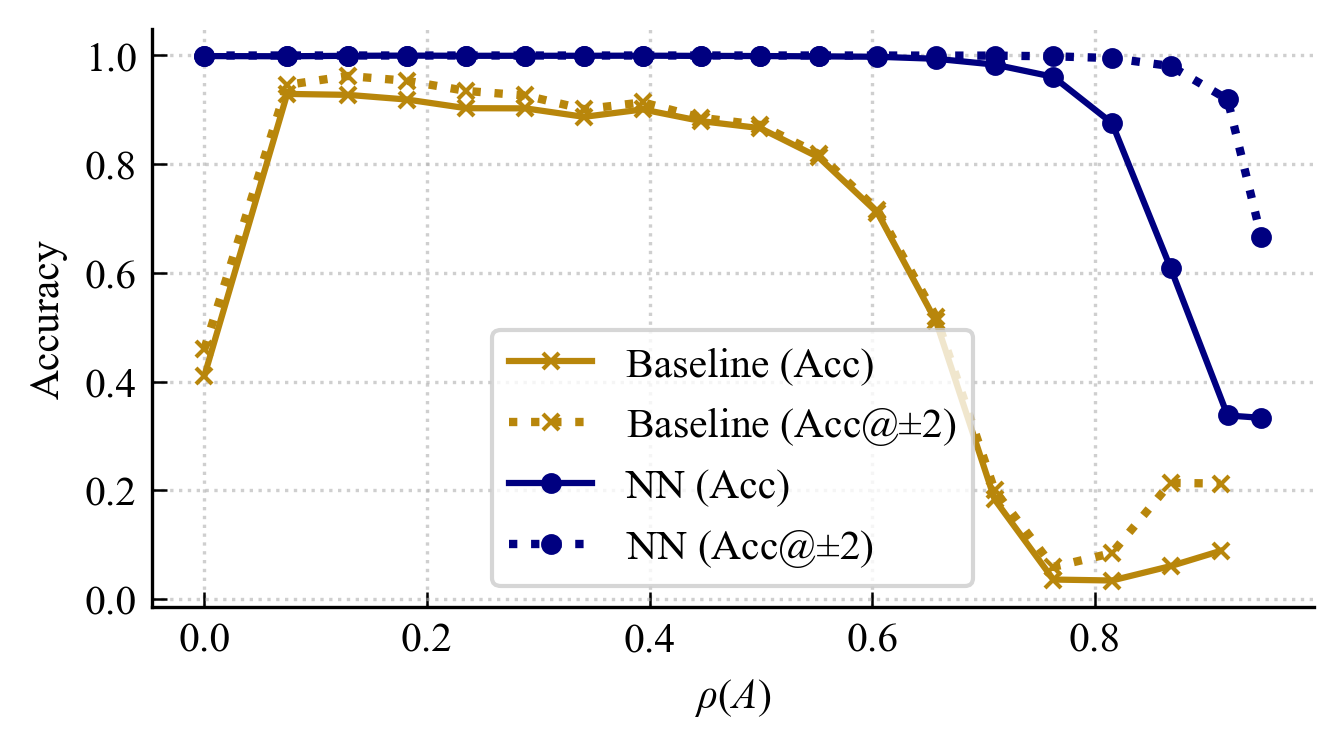

In [35]:
fig, ax = plt.subplots(figsize=(5, 2.5))

bins = np.linspace(0, 1, 20)

df = plot_acc_vs_metric(
    ax=ax,
    df=naive_results,
    metric="rad",
    bins=bins,
    k=2,
    s="Baseline",
    color="darkgoldenrod",
    marker="x"
)

plot_acc_vs_metric(
    ax=ax,
    df=nn_results,
    metric="rad",
    bins=bins,
    k=2,
    s="NN",
    color="navy",
    marker="o"
)

ax.legend()
ax.set_xlabel("$\\rho(A)$")
ax.set_ylabel("Accuracy")
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("latex/images/j8_naive_b.pdf")
plt.show()